# Week 10 Clustering: Part 1(Kmeans)

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score,recall_score,
f1_score, roc_auc_score, ConfusionMatrixDisplay,confusion_matrix,classification_report,RocCurveDisplay
import matplotlib.pyplot as plt
from scipy.stats import randint

In [ ]:
datasource= "https://archive.ics.uci.edu/static/public/383/data.csv"

df_CivicalCancer = pd.read_csv(datasource, sep=',', header=0) #loading breast cancer dataset
df_CivicalCancer.sample(10, random_state=42) #printing random sample of 10 rows

In [ ]:
df_CivicalCancer = df_CivicalCancer.drop(columns=[
    "STDs: Time since first diagnosis",
    "STDs: Time since last diagnosis",
    "STDs:cervical condylomatosis",
    "STDs:AIDS"
])
binary_cols = ["Smokes (packs/year)", "IUD (years)", "STDs (number)", "Hormonal Contraceptives (years)"]
df_CivicalCancer[binary_cols] = df_CivicalCancer[binary_cols].fillna(0)

#df_CivicalCancer[num_cols] = df_CivicalCancer[num_cols].fillna(df_CivicalCancer[num_cols].median())
df_CivicalCancer["Number of sexual partners"] = df_CivicalCancer["Number of sexual partners"].
fillna(df_CivicalCancer["Number of sexual partners"].median())
df_CivicalCancer["Num of pregnancies"] = df_CivicalCancer["Num of pregnancies"].
fillna(df_CivicalCancer["Num of pregnancies"].median())
df_CivicalCancer["First sexual intercourse"] = df_CivicalCancer["First sexual intercourse"].
fillna(df_CivicalCancer["First sexual intercourse"].median())
df_CivicalCancer["Smokes (packs/year)"] = df_CivicalCancer["Smokes (packs/year)"].
fillna(df_CivicalCancer["Smokes (packs/year)"].median())
df_CivicalCancer["IUD (years)"] = df_CivicalCancer["IUD (years)"].fillna(df_CivicalCancer["IUD (years)"].median())
df_CivicalCancer["STDs (number)"] = df_CivicalCancer["STDs (number)"].fillna(df_CivicalCancer["STDs (number)"].median())
df_CivicalCancer["STDs: Number of diagnosis"] = df_CivicalCancer["STDs: Number of diagnosis"].
fillna(df_CivicalCancer["STDs: Number of diagnosis"].median())

df_CivicalCancer["Hormonal Contraceptives (years)"] = df_CivicalCancer["Hormonal Contraceptives (years)"].
fillna(df_CivicalCancer["Hormonal Contraceptives (years)"].median())
df_CivicalCancer["STDs:condylomatosis"] = df_CivicalCancer["STDs:condylomatosis"].
fillna(df_CivicalCancer["STDs:condylomatosis"].median())
#df_CivicalCancer["STDs:cervical condylomatosis"] = df_CivicalCancer["STDs:cervical condylomatosis"].
fillna(df_CivicalCancer["STDs:cervical condylomatosis"].median())
df_CivicalCancer["STDs:vulvo-perineal condylomatosis"] = df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].
fillna(df_CivicalCancer["STDs:vulvo-perineal condylomatosis"].median())
df_CivicalCancer["STDs:syphilis"] = df_CivicalCancer["STDs:syphilis"].fillna(df_CivicalCancer["STDs:syphilis"].median())
df_CivicalCancer["STDs:pelvic inflammatory disease"] = df_CivicalCancer["STDs:pelvic inflammatory disease"].
fillna(df_CivicalCancer["STDs:pelvic inflammatory disease"].median())
df_CivicalCancer["STDs:genital herpes"] = df_CivicalCancer["STDs:genital herpes"].
fillna(df_CivicalCancer["STDs:genital herpes"].median())
df_CivicalCancer["STDs:molluscum contagiosum"] = df_CivicalCancer["STDs:molluscum contagiosum"].
fillna(df_CivicalCancer["STDs:molluscum contagiosum"].median())
#df_CivicalCancer["STDs:AIDS"] = df_CivicalCancer["STDs:AIDS"].fillna(df_CivicalCancer["STDs:AIDS"].median())
df_CivicalCancer["STDs:Hepatitis B"] = df_CivicalCancer["STDs:Hepatitis B"].
fillna(df_CivicalCancer["STDs:Hepatitis B"].median())
df_CivicalCancer["STDs:HPV"] = df_CivicalCancer["STDs:HPV"].fillna(df_CivicalCancer["STDs:HPV"].median())

df_CivicalCancer["Dx:HPV"] = df_CivicalCancer["Dx:HPV"].fillna(df_CivicalCancer["Dx:HPV"].mode())
df_CivicalCancer["Dx:CIN"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:CIN"].mode())
df_CivicalCancer["Dx:Cancer"] = df_CivicalCancer["Dx:CIN"].fillna(df_CivicalCancer["Dx:Cancer"].mode())

df_CivicalCancer_nw= df_CivicalCancer[["Age","Number of sexual partners","First sexual intercourse",
                 "Num of pregnancies","Smokes (packs/year)","Hormonal Contraceptives (years)","IUD (years)","STDs (number)",
                                       "STDs: Number of diagnosis",
                                    "STDs:condylomatosis", "STDs:vulvo-perineal condylomatosis",
                                    "STDs:syphilis","STDs:pelvic inflammatory disease","STDs:genital herpes",
                                    "STDs:molluscum contagiosum","STDs:Hepatitis B","STDs:HPV", "Biopsy"]]



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
#Target and Features
X= df_CivicalCancer_nw.drop(["Biopsy"], axis=1)
y= df_CivicalCancer_nw["Biopsy"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=42)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



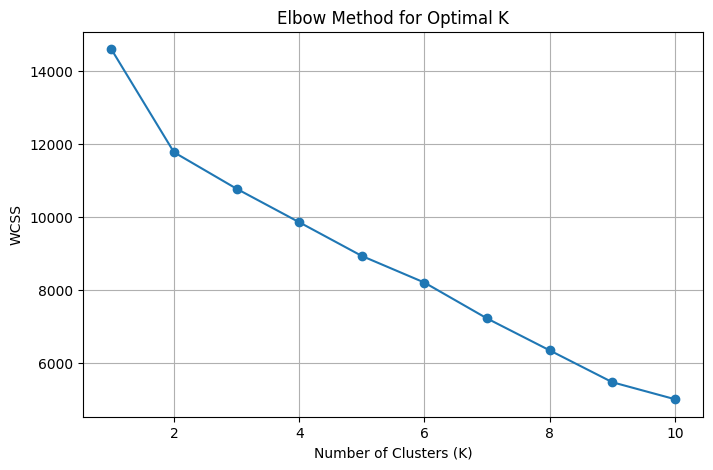

In [ ]:
#Elbow Method
wcss = []

cluster_range = range(1,11)

for k in cluster_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    cluster_range,
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.grid(True)

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster assignments
df_CivicalCancer_nw["Cluster"] = cluster_labels

/tmp/ipykernel_1706/1330343051.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CivicalCancer_nw["Cluster"] = cluster_labels


In [ ]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.6089595435010966


In [ ]:
pd.crosstab(
    df_CivicalCancer_nw["Biopsy"],
    df_CivicalCancer_nw["Cluster"]
)

Cluster,0,1
Biopsy,,
0,766,37
1,48,7


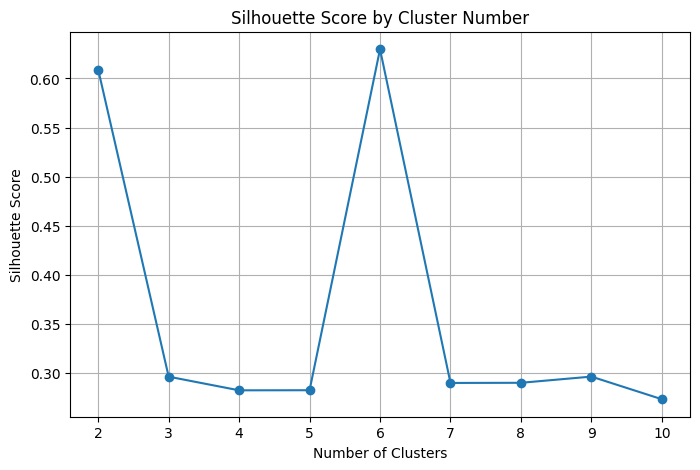

In [ ]:
#Silhouette Score by clusters
silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels)

    silhouette_scores.append(score)


plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Cluster Number")
plt.grid(True)

plt.show()

In [ ]:
#Silhouette Score by init
for n in [5,10, 25, 50, 100]:

    kmeans = KMeans(
        n_clusters=6,
        n_init=n,
        random_state=42)

    kmeans.fit(X_scaled)

    print(n, kmeans.inertia_)

5 8366.246642731681
10 8199.718668899035
25 8073.232762011759
50 8069.144285347931
100 8069.144285347931


In [ ]:
#Silhouette Score by init
for n in [5,10, 25, 50, 100]:

    kmeans = KMeans(
        n_clusters=2,
        n_init=n,
        random_state=42)

    kmeans.fit(X_scaled)

    print(n, kmeans.inertia_)

5 11766.535657508524
10 11766.535657508524
25 11766.535657508524
50 11766.535657508524
100 11766.535657508524


In [ ]:
#Compare Distance Metrics
distance_metrics = [
    "euclidean",
    "manhattan"]


for metric in distance_metrics:

    kmeans = KMeans(
        n_clusters=6,
        random_state=42,
        n_init=25)

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        metric=metric)

    print(metric, "Silhouette Score:",round(score,4))

euclidean Silhouette Score: 0.2879
manhattan Silhouette Score: 0.3053


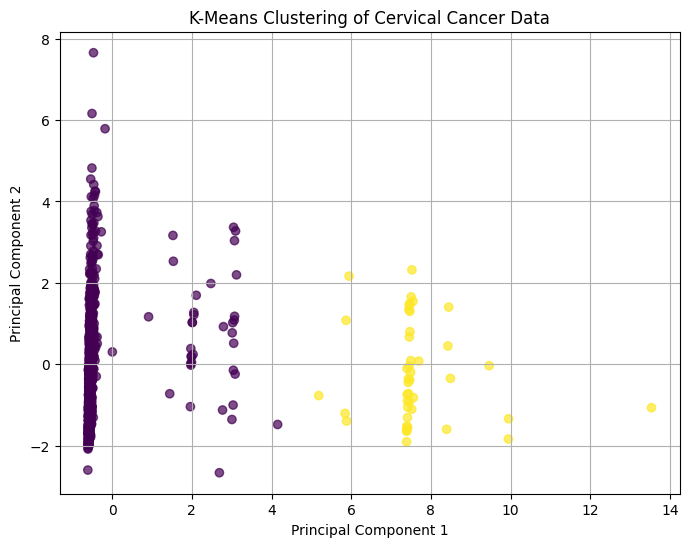

In [ ]:
#PCA Visualization of Clusters
# Fit final KMeans

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10)

clusters = kmeans.fit_predict(X_scaled)

# PCA reduction
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    alpha=0.7)


plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of Cervical Cancer Data")
plt.grid(True)
plt.show()

In [ ]:
#Compare Clusters with Actual Diagnosis (Optional)
comparison = pd.DataFrame({
    "Actual Diagnosis": df_CivicalCancer_nw["Biopsy"],
    "Cluster": clusters})

print(pd.crosstab(
        comparison["Actual Diagnosis"],
        comparison["Cluster"]))

Cluster             0   1  2   3  4  5
Actual Diagnosis                      
0                 746  35  1  18  2  1
1                  48   7  0   0  0  0


In [ ]:
#Comparison of feature scaling before and after
# Without scaling
kmeans_raw = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10)

clusters_raw = kmeans_raw.fit_predict(X)
print("Silhouette without scaling:",
    silhouette_score(X, clusters_raw))


# With scaling
kmeans_scaled = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters_scaled = kmeans_scaled.fit_predict(X_scaled)
print("Silhouette with scaling:",
    silhouette_score(X_scaled, clusters_scaled))

Silhouette without scaling: 0.43718673231278704
Silhouette with scaling: 0.6089595435010966


In [ ]:
#Print cluster centroids (scaled + unscaled)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
centroids_scaled = kmeans.cluster_centers_
centroids_unscaled = scaler.inverse_transform(centroids_scaled)
print(pd.DataFrame(centroids_unscaled, columns=X.columns))

print("Explained variance:", pca.explained_variance_ratio_)

         Age  Number of sexual partners  First sexual intercourse  \
0  26.787154                   2.483627                 17.002519   
1  26.523810                   2.809524                 17.571429   
2  33.000000                   4.000000                 17.000000   
3  27.833333                   2.833333                 15.166667   
4  34.000000                   3.000000                 19.000000   
5  27.000000                   4.000000                 16.000000   

   Num of pregnancies  Smokes (packs/year)  Hormonal Contraceptives (years)  \
0            2.238035             0.446247                     1.949086e+00   
1            2.071429             0.509838                     2.261667e+00   
2            0.000000             0.000000                     7.500000e-01   
3            3.666667             0.389622                     2.055556e+00   
4            1.500000             0.080000                     6.000000e+00   
5            4.000000             0.000000

In [ ]:
#Compute Adjusted Rand Index (ARI)
from sklearn.metrics import adjusted_rand_score
print("ARI:", adjusted_rand_score(y, clusters))

ARI: 0.045189127324551236


In [ ]:
#feature importance analysis for clusters
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
cluster_means = df_CivicalCancer_nw.groupby("Cluster").mean()
print(round(cluster_means,4))

             Age  Number of sexual partners  First sexual intercourse  \
Cluster                                                                 
0        26.8477                     2.4975                   16.9730   
1        26.3182                     2.7727                   17.4091   

         Num of pregnancies  Smokes (packs/year)  \
Cluster                                            
0                    2.2678               0.4424   
1                    2.0682               0.5185   

         Hormonal Contraceptives (years)  IUD (years)  STDs (number)  \
Cluster                                                                
0                                 1.9586       0.4301         0.0442   
1                                 2.2270       0.7120         2.2045   

         STDs: Number of diagnosis  STDs:condylomatosis  \
Cluster                                                   
0                           0.0381                  0.0   
1                           1.00

Across clustering methods, performance was evaluated using WCSS (Elbow Method), Silhouette Score, cluster centroids, and Adjusted Rand Index (ARI). The Elbow plot showed no clear bend, suggesting weak cluster separation, while the Silhouette Score for K = 2 (0.609) indicated two mathematically well-defined clusters. However, these clusters did not align with the biopsy labels: Cluster 0 contained 766 benign and 48 malignant cases, while Cluster 1 contained 37 benign and 7 malignant cases. The low ARI (0.045) confirmed minimal agreement between clusters and true diagnoses. PCA visualization showed overlapping groups, and Euclidean and Manhattan distance metrics produced similarly low Silhouette Scores for higher K values. Overall, K-Means identified coherent feature-space clusters, but they did not correspond to clinical outcomes, highlighting the dataset's weak signal and class imbalance.